# Olist E-Commerce Data Analysis

## Objective

This project explores the Olist E-commerce dataset from Kaggle using SQL and Python to answer business-relevant questions related to sales performance, delivery reliability and customer satisfaction.

## Project Overview
The Olist Database contains information about:
1. Orders, including items, products, product categories and reviews
2. Customer and payment data, including geolocation information

## Business Questions Explored
1. Which tables are included in the Olist Database (What data do we have?)? 
2. How large is the dataset in e.g. the orders table?
3. What time period does the data cover?
4. What are the top 20 product categories by revenue of the sample?
5. How many orders were placed per year and what percentage of them were delayed?
6. How did the customers review their orders in 2017 and 2018?

In [1]:
import sqlite3, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('./data/olist.db')
cursor = conn.cursor()

In [3]:
# Q1: Which tables are included in the Olist Database?
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('orders',), ('order_items',), ('order_payments',), ('order_reviews',), ('products',), ('sellers',), ('customers',), ('geolocation',), ('category_translation',)]


In [4]:
# Q2: How large is the dataset in e.g. the orders table?
q2 = 'SELECT COUNT(*) AS total_orders FROM orders;'

In [5]:
display(pd.read_sql(q2, conn))

,total_orders
0,99441


In [6]:
# Q3: What time period does the data cover?
q3 = 'SELECT MIN(order_purchase_timestamp) AS first_order, MAX(order_purchase_timestamp) AS last_order FROM orders;'

In [7]:
display(pd.read_sql(q3, conn))

,first_order,last_order
0,2016-09-04 21:15:19,2018-10-17 17:30:18


In [8]:
# Q4: What are the top 20 product categories by revenue of the sample?
q4 = """
SELECT
    p.product_category_name,
    ROUND(SUM(oi.price) / 1000000.0, 4) AS revenue_per_mio

FROM order_items AS oi

LEFT JOIN products AS p
    ON oi.product_id = p.product_id

GROUP BY p.product_category_name

ORDER BY revenue_per_mio DESC

LIMIT 20;
"""

In [9]:
display(pd.read_sql(q4, conn))

,product_category_name,revenue_per_mio
0,beleza_saude,1.2587
1,relogios_presentes,1.2050
2,cama_mesa_banho,1.0370
3,esporte_lazer,0.9880
4,informatica_acessorios,0.9120
5,moveis_decoracao,0.7298
6,cool_stuff,0.6353
7,utilidades_domesticas,0.6322
8,automotivo,0.5927
9,ferramentas_jardim,0.4853


In [10]:
# Q5: How many orders were placed per year and what percentage of them were delayed?
q5 = """
SELECT 
    strftime("%Y", order_purchase_timestamp) AS year, 
    count(*) AS orders,
    SUM(
        CASE WHEN order_delivered_customer_date > order_estimated_delivery_date 
            THEN 1 
            ELSE 0 
        END
    ) AS delayed_orders,
    ROUND(
        100.0 * SUM(
        order_delivered_customer_date > order_estimated_delivery_date
        ) / count(*), 2
    ) AS delayed_percentage

FROM orders 

GROUP BY strftime("%Y", order_purchase_timestamp)

ORDER BY year;
"""

In [11]:
display(pd.read_sql(q5,conn))

,year,orders,delayed_orders,delayed_percentage
0,2016,329,4,1.22
1,2017,45101,2878,6.38
2,2018,54011,4945,9.16


## Review Score Distribution Analysis
### Q6: How did the customers review their orders in 2017 and 2018?
This query analyzes customer review scores by:
- total review count
- yearly review trends (2017 vs 2018)
- percentage contribution of each score

A CTE is used to improve readability and separate aggregation logic.

In [12]:
# Q6: How did the customers review their orders in 2017 and 2018?
q6 = """
WITH CTE AS (
    SELECT 
        review_score, 
        COUNT(review_score) AS review_count,
        SUM(
            CASE 
                WHEN strftime('%Y', review_creation_date) = '2017' 
                THEN 1 
                ELSE 0
            END
        ) AS Y_2017,
        SUM(
            CASE 
                WHEN strftime('%Y', review_creation_date) = '2018' 
                THEN 1 
                ELSE 0
            END
        ) AS Y_2018
    FROM order_reviews
    GROUP BY review_score
)
SELECT 
    review_score,
    review_count,
    Y_2017,
    Y_2018,
    ROUND(
        review_count * 100.0 / SUM(review_count) OVER (),
        2
    ) AS score_perc

FROM CTE
ORDER BY review_score DESC;
"""

In [13]:
display(pd.read_sql(q6,conn))

,review_score,review_count,Y_2017,Y_2018,score_perc
0,5,57328,24759,32413,57.78
1,4,19142,8440,10651,19.29
2,3,8179,3589,4568,8.24
3,2,3151,1350,1793,3.18
4,1,11424,4597,6739,11.51


In [14]:
df = pd.read_sql(q6,conn)

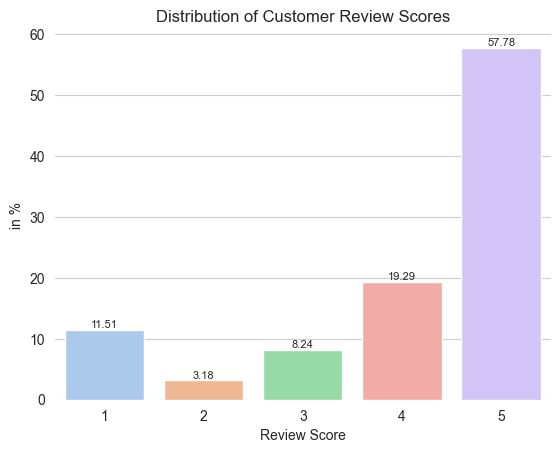

In [26]:
ax = sns.barplot(
    x='review_score', 
    y='score_perc',
    data=df, 
    hue='review_score', 
    palette='pastel', 
    errorbar = None, 
    legend = False
)

plt.title('Distribution of Customer Review Scores')

ax.set(
    xlabel = 'Review Score', 
    ylabel = 'in %'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

sns.set_style('whitegrid')

#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1)) optional legend positioned besides the plot

sns.despine(top=True, right=True, left=True, bottom=True)

plt.show()

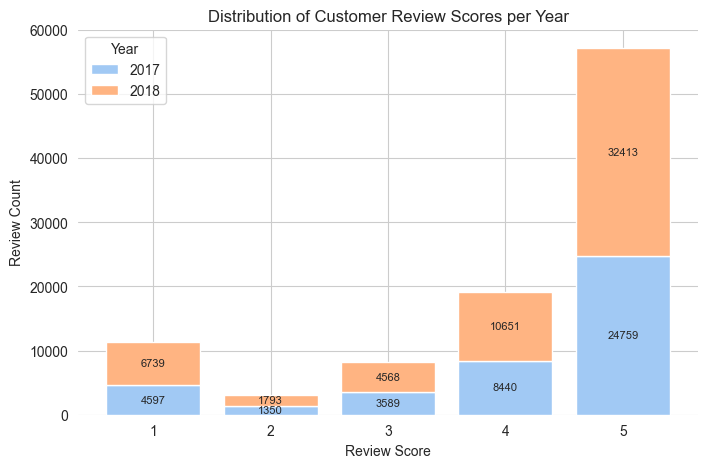

In [29]:
fig, ax2 = plt.subplots(figsize=(8,5))

ax2.bar(
    df['review_score'],
    df['Y_2017'],
    label='2017',
    color=sns.color_palette('pastel')[0]
)

ax2.bar(
    df['review_score'],
    df['Y_2018'],
    bottom=df['Y_2017'],
    label='2018',
    color=sns.color_palette('pastel')[1]
)

plt.title('Distribution of Customer Review Scores per Year')

ax2.set(
    xlabel='Review Score',
    ylabel='Review Count'
)

# Add labels inside/on bars
for i in range(len(df)):
    
    #Order of Scores needs to be reversed
    reversed_df = df.iloc[::-1].iloc[i]

    x_value = reversed_df['review_score']

    y2017 = reversed_df['Y_2017']
    y2018 = reversed_df['Y_2018']
    
    # 2017 label
    ax2.text(
        x=x_value,
        y=y2017 / 2,
        s=str(int(y2017)),
        ha='center',
        va='center',
        fontsize=8
    )

    # 2018 label
    ax2.text(
        x=x_value,
        y=y2017 + (y2018 / 2),
        s=str(int(y2018)),
        ha='center',
        va='center',
        fontsize=8
    )
    
ax2.set(
    xlabel='Review Score',
    ylabel='Review Count'
)
sns.set_style('whitegrid')
ax2.legend(title='Year')

sns.despine(top=True, right=True, left=True, bottom=True)

plt.show()

## Key Takeaways
- It becomes visible, that the number of 4 and espescially the desirable 5-Score Reviews has increased compared to the year before
- Further, it needs to be researched where this improvement stems from (like improvements in product popularity, product quality or 'simply' better performance of shipping or customer care etc.) 

## Ideas for further research 
- Deep dive into the "score-5" products and categories. 
- Searching for specific reasons that led to 1-score reviews.

In [16]:
conn.close()